In [86]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [87]:
output_root = "budget_results"
output_dir = os.path.join(output_root, "ode")
wd_nn_array = np.load(os.path.join(output_dir, "wd_nn_array_mean.npy"))
wd_mcmc_array = np.load(os.path.join(output_root, "wd_mcmc_array_mean.npy"))
wd_nn_std = np.load(os.path.join(output_dir, "wd_nn_array_std.npy"))
wd_mcmc_std = np.load(os.path.join(output_root, "wd_mcmc_array_std.npy"))

budget = 4 ** 8
conditioning_list = [4 ** i for i in range(9)]

In [88]:
wd_nn_array

array([0.05274082, 0.16136068, 0.12267308, 0.14442101, 0.2658556 ,
       0.44822092, 0.84794306, 1.6429997 , 3.904963  ])

In [92]:
wd_mcmc_array

array([0.01020667, 2.57666441, 2.17377587, 3.00523225, 3.14795919,
       2.87257589, 3.07282362, 3.42860352, 3.69476925])

In [100]:
wd_nn_array[::-1]

array([3.904963  , 1.6429997 , 0.84794306, 0.44822092, 0.2658556 ,
       0.14442101, 0.12267308, 0.16136068, 0.05274082])

Text(0, 0.5, 'W2 Error')

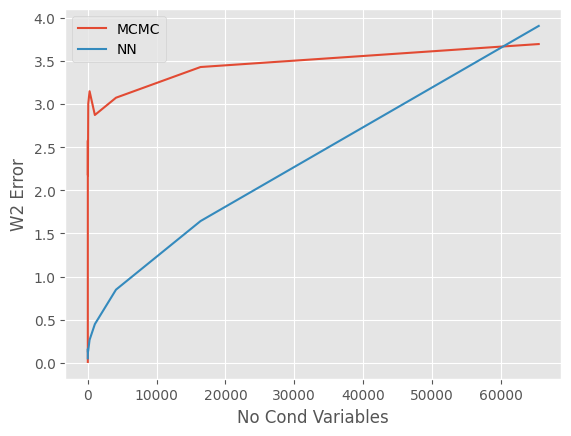

In [104]:
plt.plot(conditioning_list, wd_mcmc_array, label="MCMC")
plt.plot(conditioning_list, wd_nn_array, label="NN")
plt.legend()
# plt.yscale("log")
# plt.xscale("log")
plt.xlabel("No Cond Variables")
plt.ylabel("W2 Error")

In [55]:
nn_samps = np.load("nn_results/ode/nn_samps_1024_64.npy")
cond_vars = np.load("nn_results/ode/cond_vars_64.npy")
np.unique(np.isnan(nn_samps))

array([False,  True])

In [63]:
cond_vars[49]

np.float64(1.5765588923716285)

In [57]:
nn_samps.shape

(1024, 64)

In [85]:
nn_samps[~np.isnan(nn_samps)]
nn_samps.shape

(1024, 64)

In [58]:
mask = np.where(np.isnan(nn_samps))
mask = list(zip(*mask))

In [65]:
np.unique(nn_samps[:, 7])

array([nan], dtype=float32)

In [60]:
mask

[(np.int64(0), np.int64(7)),
 (np.int64(0), np.int64(36)),
 (np.int64(0), np.int64(49)),
 (np.int64(1), np.int64(7)),
 (np.int64(1), np.int64(36)),
 (np.int64(1), np.int64(49)),
 (np.int64(2), np.int64(7)),
 (np.int64(2), np.int64(36)),
 (np.int64(2), np.int64(49)),
 (np.int64(3), np.int64(7)),
 (np.int64(3), np.int64(36)),
 (np.int64(3), np.int64(49)),
 (np.int64(4), np.int64(7)),
 (np.int64(4), np.int64(36)),
 (np.int64(4), np.int64(49)),
 (np.int64(5), np.int64(7)),
 (np.int64(5), np.int64(36)),
 (np.int64(5), np.int64(49)),
 (np.int64(6), np.int64(7)),
 (np.int64(6), np.int64(36)),
 (np.int64(6), np.int64(49)),
 (np.int64(7), np.int64(7)),
 (np.int64(7), np.int64(36)),
 (np.int64(7), np.int64(49)),
 (np.int64(8), np.int64(7)),
 (np.int64(8), np.int64(36)),
 (np.int64(8), np.int64(49)),
 (np.int64(9), np.int64(7)),
 (np.int64(9), np.int64(36)),
 (np.int64(9), np.int64(49)),
 (np.int64(10), np.int64(7)),
 (np.int64(10), np.int64(36)),
 (np.int64(10), np.int64(49)),
 (np.int64(11), np

In [42]:
nn_samps

array([[ 4.6369843 ,  6.0226564 ,  0.7336612 , ..., -3.102712  ,
        -0.81309277,  5.8210287 ],
       [-4.996909  , -5.8673244 ,  1.2264869 , ...,  3.5940585 ,
        -3.160813  , -5.962446  ],
       [-5.107457  , -6.5949426 ,  2.237522  , ...,  3.7267337 ,
         1.3701794 , -5.6452317 ],
       ...,
       [-5.6446285 ,  6.276784  , -2.1577902 , ...,  3.9860508 ,
         0.29331416,  5.511489  ],
       [-4.938719  ,  6.139382  , -1.0359218 , ...,  3.3155727 ,
         1.2600999 ,  5.549512  ],
       [ 2.722649  ,  6.2136707 , -2.8925126 , ...,  4.147735  ,
         1.5207375 ,  5.809063  ]], shape=(1024, 64), dtype=float32)

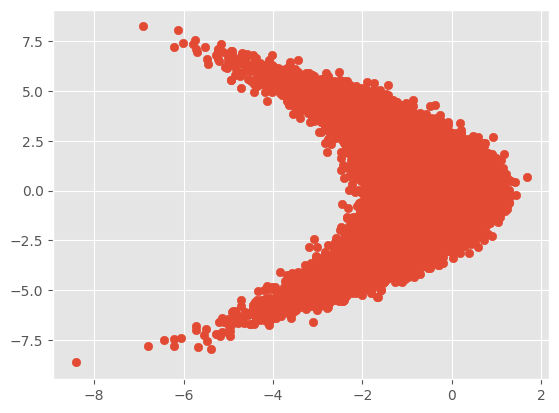

In [66]:
from triangular_transport.flows.methods.sampling import inf_train_gen
target_data = inf_train_gen(data="banana", rng=None, batch_size=budget)
plt.scatter(target_data[:, 0], target_data[:, 1])

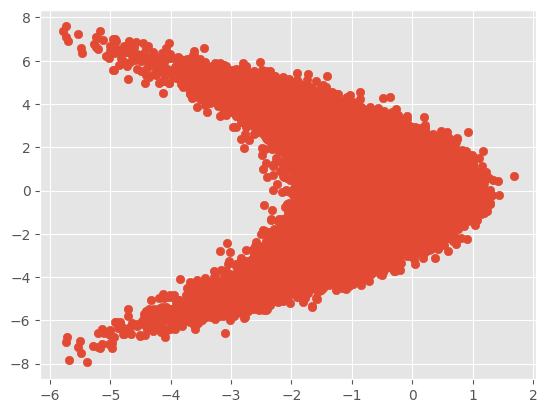

In [82]:
sub_data = target_data[np.where(target_data[:, 0] >= -6)[0]]
plt.scatter(sub_data[:, 0], sub_data[:, 1])

In [77]:
np.where(target_data[:, 0] >= 1.0)

(array([  200,  2304,  3889,  3964,  4859,  6934,  8541, 10894, 10989,
        11388, 11709, 13494, 15805, 16100, 16431, 17925, 18311, 19279,
        19826, 21210, 21255, 21778, 22481, 23786, 23842, 24328, 24884,
        25576, 26303, 26701, 30114, 30164, 30565, 31000, 31792, 32115,
        34320, 34836, 35196, 35322, 36159, 38090, 38249, 39510, 42396,
        43822, 46412, 46687, 46711, 46790, 47014, 48250, 48351, 49342,
        50649, 51254, 51893, 52166, 54206, 55660, 56929, 57522, 59152,
        60902, 61018, 62442, 62987, 63521]),)

In [76]:
np.max(target_data[:, 0])

np.float64(1.6780082795173554)

In [69]:
cond_vars[49]

np.float64(1.5765588923716285)

In [71]:
cond_vars[36]

np.float64(1.7298035568642156)